# Flattening an Eclipsing Binary Lightcurve Using BoxLeastSquares and Lightkurve
## Author
Aidan Niklaus

## Citations and Acknowledgements
astropy + lightkurve prolly

## Learning Outcomes


## Keywords

## Summary

## Note to Reader


## Installation
If this is your first time using Lightkurve, you will need to install it using pip. This can be done in the terminal by typing "python -m pip install lightkurve --upgrade", or within Jupyter Notebook using the "%" prefix (code block below).

In [37]:
# I have already done this, so will comment it out to reduce the length of this tutorial

# # '--upgrade' automatically installs updates
# %pip install lightkurve --upgrade

## Imports

In [38]:
import numpy as np
import lightkurve as lk
from astropy.timeseries import BoxLeastSquares
import matplotlib.pyplot as plt
%matplotlib inline

## Step 0: The Problem
#### 0.1: Making an Example Lightkurve
In order to demonstrate Astropy's BoxLeastSqaures flattening method for eclipsing binaries, as well as why we need to use it, we first need an example lightcurve with which to work. The following code does this, but without much explanation. If you would like to learn in depth how to create a lightcurve from scratch, please refer to [THIS](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/03_FFI_LC_Decision_Tree_Tutorial.ipynb) tutorial. If you already have a lightcurve to work with, simply skip to "0.2: Why We Cannot Use 'flatten()'", noting that this tutorial stores it's lightcurve as the variable "lc".

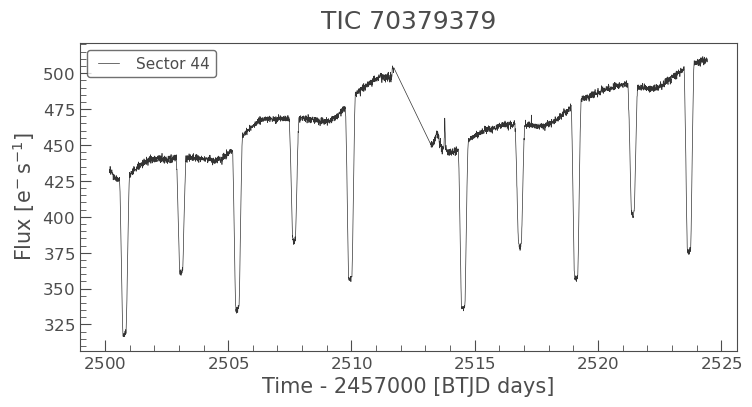

In [40]:
# Setting our target star and sector we will be using to make our lightcurve
target = "TIC 70379379"
sector = 44

# target : the star we want to work with; the following naming formats are acceptable
    # name, e.g. "HAT-P-11"
    # identifying number, e.g. "TIC 408036613"
    # RA Dec coordinates, e.g. "285.67942179 +50.24130576" (decimal format) or "19:02:43.1 +50:14:28.7" (sexagesimal format)
    # an astropy.coordinates.SkyCoord object
search_result = lk.search_tesscut(target=target, sector=sector)

# cutout_size : specifies the TPF size ("cropped" from the FFI), in this example, we asked for a 20x20 pixel TPF
tpf = search_result[0].download(cutout_size=20)

# Creating aperture mask of our target star
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')

# Creating an initial lightcurve of our target star using our target mask
initial_lc = tpf.to_lightcurve(aperture_mask=target_mask)

# Creating aperture mask of the background (to capture inherent background noise that is not taken out by quality mask)
background_mask = ~tpf.create_threshold_mask(threshold=0.001, reference_pixel=None)

# Grabbing the amount of pixels in each of our masks to ultimately use to filter out average background noise
n_target_pixels = target_mask.sum()
n_background_pixels = background_mask.sum()

# Making an average noise per pixel lightcurve
background_lc_per_pixel = (tpf.to_lightcurve(aperture_mask=background_mask) / n_background_pixels)

# Multiplying our average noise per pixel lightcurve by the amount of pixels in our target mask to find a lightcurve 
    # representing the total noise present in our star pixels
noise_lc = background_lc_per_pixel * n_target_pixels

# Subtracting the total noise lightcurve from the original lightcurve to get our corrected lightcurve
lc = initial_lc - noise_lc

# Plotting our lightcurve to see what we got!
lc.plot(title=target, label=f"Sector {sector}");

#### 0.2: Why We Cannot Use 'flatten()'
Within the package Lightkurve is a built-in flattening function, so why can't we just use that? Well, let's try it...

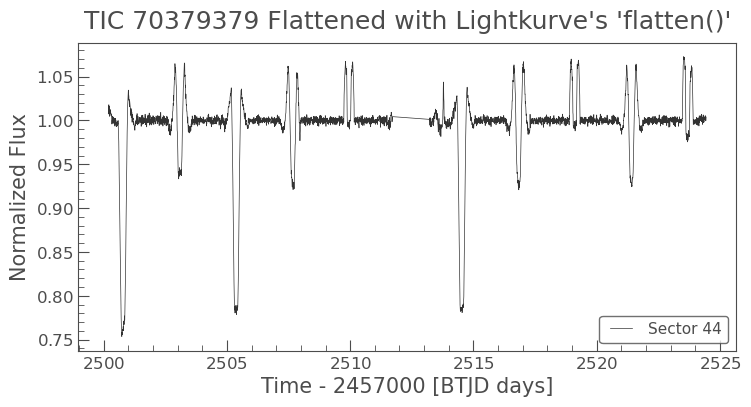

In [80]:
# Flattening the lightcurve above then replotting it
flat_lc = lc.flatten()
flat_lc.plot(title=f"{target} Flattened with Lightkurve's 'flatten()'", label=f"Sector {sector}");

As you can see, each eclipse has an up-spike before and after the dip, almost resembling shoulders. This is a result of Lightkurve's 'flatten()' function trying to fit our lightcurve with too low an order of polynomial, meaning its smooth nature prevents it from appropriately fitting the aggressive down-spikes customary of eclipsing binaries.

#### 0.3: The Fix
Astropy's BoxLeastSquares (BLS) fixes this issue by using square waves, as they are much more tailored to sharp dips. Futhermore, BLS is meant to be ran on the primary (larger) and secondary (smaller) eclipses separately as this results in a more accurate fit for each one. Using BLS will allow us to fully identify both eclipses, then mask them off *before* flattening our light curve, in turn getting rid of the "shoulders" and allowing us to clearly visualize our star.

## Step 1: Setting up BoxLeastSquares (BLS) on the Primary Eclipse
Great! Now that we have a little context as to why we must use BLS, let's get started on our primary eclipse!

Regardless of primary or secondary eclipse, BLS requires two things to run: the data to which to fit itself and a list of possible orbital periods for our star, called a "period grid". Let's start by grabbing that data, which is conveniently held within the lightcurve we just made, and giving it to BLS. Note: BLS is simply receiving this data, not running or computing anything yet.

In [50]:
# Grabbing lc data and putitng into plain arrays that BLS accepts
time = lc.time.value
flux = lc.flux.value
# Don't technically need flux_err, but since lightkurve already gives it to us, might as well pass it along to BLS
flux_err = lc.flux_err.value

# Giving BLS the data it needs and creating the BLS model from it (no actual computation yet)
primary_bls = BoxLeastSquares(time, flux, flux_err)

Next, let's make our period grid. If you already know the rough period of your eclipsing binary, you can focus your grid to only include points around that area; but for this example, we will have our range be between 0.5 and 20 days as that should encompass most eclipsing binaries.

In [51]:
# Populating a list of potential period candidates --> 10,000 possible points between 0.5-20 days on a logarithmic scale
period_grid = np.exp(np.linspace(np.log(0.5), np.log(20), 10000))

## Step 2: Running BLS and Masking the Primary Eclipse
Now that BLS has all the information it needs, let's run it! Note: despite the lightcurve data we provided including both primary and secondary eclipses, BLS will automatically fit itself to the deepest set of dips (primary eclipse), meaning we don't have to worry about accidently fitting the secondary eclipse instead.

In [52]:
# Actual computation occuring. For every possible period in our period grid, BLS...
    # Phase folds the data at that period
    # Tries to fit "boxes" on the eclipse
    # Groups all its attempts into eclipse or not-eclipse categories, which it uses to define a good fit model
# duration : variety of durations (in days) BLS will test eclipses at
# oversample : higher = more accurate fits but slower, rarely need to go higher than 20
primary_result = primary_bls.power(period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

Sweet! Now that BLS has run, there are a few things we want to grab from its result.
- the index of BLS's best guess for our star's period ('primary_result.power' is a periodogram BLS made, 'np.argmax' finds the index of the strongest peak (strongest peak = most likely period))

Using that index, we can grab:

- period
- reference eclipse time
- eclipse duration

We can use this information to create the mask of our primary eclipses and in turn prevent them from being inaccurately flattened.

In [71]:
# In order from top to bottom: index of BLS's best period guess, that period itself, reference eclipse time, eclipse duration
primary_i = np.argmax(primary_result.power)
primary_period = primary_result.period[primary_i]
primary_t0 = primary_result.transit_time[primary_i]
primary_duration = primary_result.duration[primary_i]

# Creating the mask for the primary (bigger) eclipse using the info grabbed above true for points inside the eclipse, false for points outside)
    # Multiplying duration by 1.5 to pad the mask on either side to be safe
primary_mask = primary_bls.transit_mask(time, primary_period, primary_duration * 1.5, primary_t0)

Now that we have identified and masked our primary eclipse, let's repeat the process for our secondary eclipse (with a few minor changes).

## Step 3: Re-Running BLS and Masking the Secondary Eclipse
When running BLS on our secondary eclipse, we can use the same period grid (list of period guesses), but cannot give BLS the same set of data. As aforementioned, BLS automatically fits itself to the deepest dips, meaning we need to figure out a way to tell BLS to skip over the primary eclipse and focus on the secondary eclipse instead. Conveniently for us, we just made a mask of the primary eclipse, meaning if we flip it, we will have a mask where the secondary dips are the deepest because there will be no primary dips present.

In [59]:
# Making another mask that is the exact opposite of the primary mask bc that way BLS only looks at points that are not part of the primary eclipse
not_primary_mask = ~primary_mask

# Applying the above mask to omit the primary eclipse from the data we give to BLS
secondary_bls = BoxLeastSquares(time[not_primary_mask], flux[not_primary_mask], flux_err[not_primary_mask])

Now that BLS has the data it needs to find and fit the secondary eclipse, we can repeat the same run process as before, only this time grabbing information to make a mask of our secondary eclipse.

In [60]:
# Running BLS again with the same period grid but now with the masked data
secondary_result = secondary_bls.power(period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

# Grabbing (in order from top to bottom): index of BLS's best period guess, that period itself, reference eclipse time, eclipse duration
secondary_i = np.argmax(secondary_result.power)
secondary_period = secondary_result.period[secondary_i]
secondary_t0 = secondary_result.transit_time[secondary_i]
secondary_duration = secondary_result.duration[secondary_i]

# Creating the secondary eclipse mask using the info grabbed above (padded the same as primary)
secondary_mask = secondary_bls.transit_mask(time, secondary_period, secondary_duration * 1.5, secondary_t0)

## Step 4: Confirmation Using Phase-Folding and Period
Before we combine the two masks, then reflatten and replot our curve, let's confirm that BLS accurately identified each of our eclipses. We can do that by folding our lightcurve on what BLS thought our star's period was when it fit itself to each eclipse. In an ideal world, BLS came up with the same period for our star during both its runs and when we fold our lightcurve on that period, it shows one, clear orbit. However, sometimes BLS accidently thinks the period is a factor/multiple of the true period, causing the initial graph to appear wacky, but in reality a simple algabraic adjustment gives us the matching periods and singular folded cycle we are looking for.

Just like 'flatten()', 'fold()' is a built in Lightkurve function. It requires the period on which to fold it, as well as a reference start time---both of which we have for each eclipse!

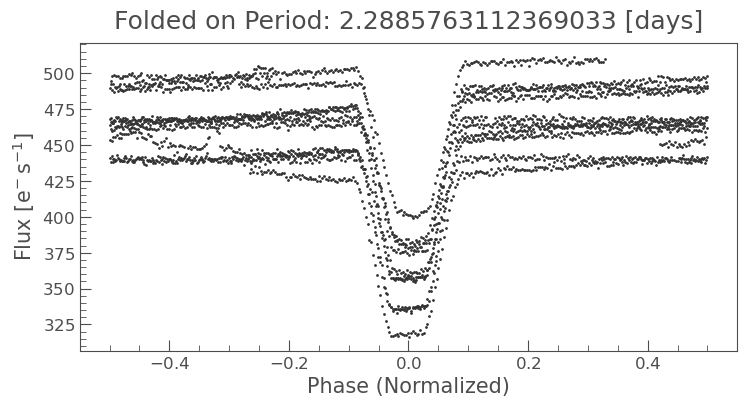

In [72]:
# Folding our lightcurve on the period BLS concluded on during its primary run
    # period : orbital period we want to fold our graph on (increments to cut up our graph and then layer on top of each other)
    # epoch_time : reference start time (may need to adjust this to help with visual confirmation)
    # normalize_phase : makes time dimensionless value (helpful for visual confirmation)
primary_folded_lc = lc.fold(period=primary_period, epoch_time=primary_t0, normalize_phase=True)
primary_folded_lc.scatter(title=f"Folded on Period: {primary_period} [days]");

Folding is kinda like cutting up your curve in increments of whatever period length you provided, then layering those cuts on top of each other. In this scenario, both the primary and secondary eclipses are layered directly on top of each other, meaning our cut was half of what it shoudld have been. In other words, our cuts only lasted half a cycle. Let's try doubling the period and regraphing.

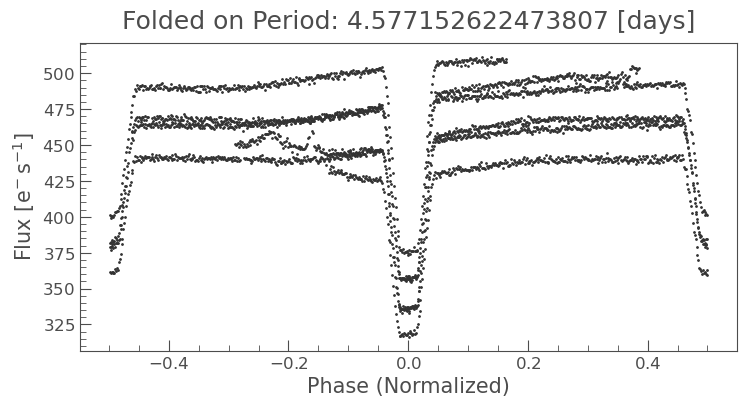

In [75]:
# Multiplying the existing period by 2 and storing it
true_period = primary_period * 2

# Refolding lightcurve with new period
folded_lc = lc.fold(period=true_period, epoch_time=primary_t0, normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {true_period} [days]");

That looks more like a full cycle! Let's shift the graph over so we can see the two dips more clearly. We can do this by either adding to, or subtracting from, the start/reference time.

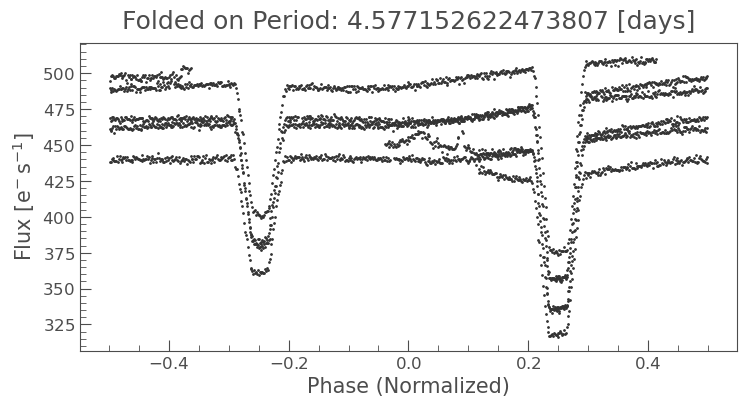

In [76]:
# New reference time will shift our graph over by a quarter or a cycle, allowing us to clearly see both dips
adjusted_reference_time = primary_t0 - true_period / 4

# Refolding lightcurve with new period and new reference time
folded_lc = lc.fold(period=true_period, epoch_time=adjusted_reference_time, normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {true_period} [days]");

Nice! Now that we can fully see both eclipses, and our graph is folded to one full cycle, we can confidently say that our star's true orbital period is roughly 4.57 days. Let's check and see if BLS's guess for the period during its secondary run matches this number.

Note: the reason some of the layers appear higher than others is because the original lightcurve's flux gradually increases over time.

In [77]:
print(f"True period: {true_period}")
print(f"BLS Secondary run guess: {secondary_period}")

True period: 4.577152622473807
BLS Secondary run guess: 13.611889892850137


They are not the same, but don't fear! Similarly to how BLS's primary run guess was half the true period, it looks like BLS's secondary run guess was three times the truth. Let's check that for sanity.

True period: 4.577152622473807
BLS Secondary run guess adjusted: 4.5372966309500455


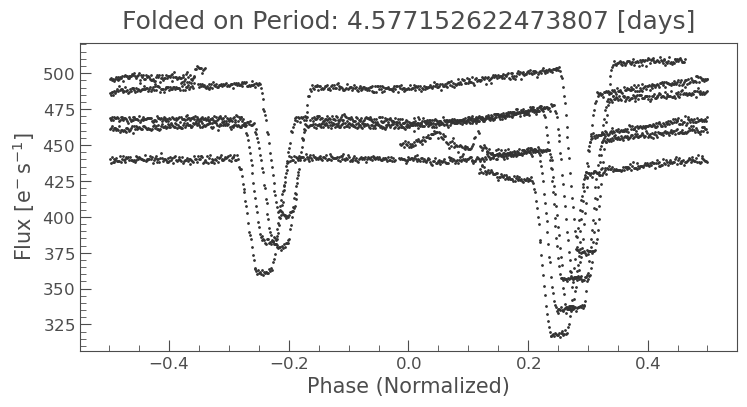

In [78]:
print(f"True period: {true_period}")
print(f"BLS Secondary run guess adjusted: {secondary_period / 3}")

folded_lc = lc.fold(period=secondary_period / 3, epoch_time=adjusted_reference_time, normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {true_period} [days]");

Great! Even after proper factoring/multiplying, the periods don't 100% match, but they are close enough that we can safely conclude BLS successfully identified the eclipses properly, and in turn they will be completely masked off when we re-flatten our graph.

## Step 5: Combining the Masks and Re-Flattening
Now that we have confirmed our masks are sound, let's combine them!

In [79]:
# Combining the two masks using OR logic
eclipse_mask = primary_mask | secondary_mask

Great! Now all we have to do is re-flatten our graph, except this time tell Lightkurve to not worry about any points within the eclipse mask we just made.

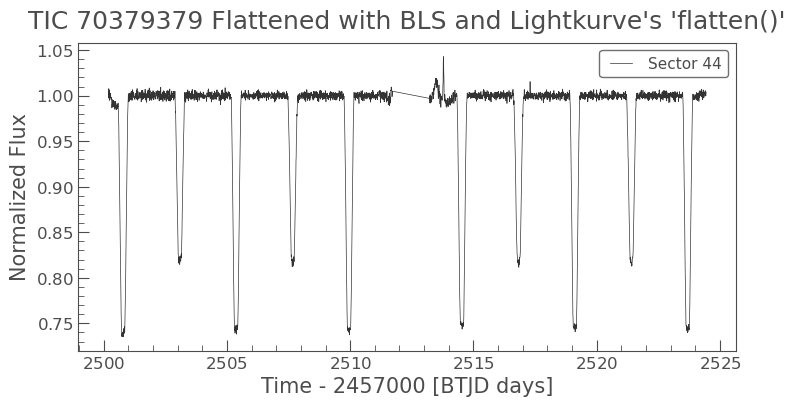

In [82]:
# Flattening the data with the eclipsing binary mask applied!
BLS_flattened_lc = lc.flatten(mask=eclipse_mask)

# Plotting the newly flattened lightcurve to see what we got!
BLS_flattened_lc.plot(title=f"{target} Flattened with BLS and Lightkurve's 'flatten()'", label=f"Sector {sector}");

Very pretty! The shoulders are gone, the curve is flat, but the eclipses are preserved, just like we wanted! But what if your curve doesn't look like this---or maybe BLS wasn't able to produce anything at all... This is often the case of working with noisy lightcurves as their spiky nature tends to make BLS think everything is an eclipse even when it's not. The following bonus section covers how to fix this with period guessing.

## Bonus: Using a Period Guess to Work with Particularly Noisy Lightcurves
